# Nike Sales Dataset — Cleaning & Imputation

In this notebook **Nike_Sales_Uncleaned.csv** dataset is clean step by step


## 0. Libraries Import & Data Load

For Standard data-cleaning `pandas` and `numpy` is enough

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


INPUT_PATH = '/mnt/user-data/uploads/1783148215124_Nike_Sales_Uncleaned.csv'
OUTPUT_PATH = '/mnt/user-data/outputs/Nike_Sales_Cleaned.csv'

df = pd.read_csv('Nike_Sales_Uncleaned.csv')
print(f"Original shape: {df.shape}")
df.head()

Original shape: (2500, 13)


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89


## 1. Region Column — Standardization

**Nature:** `Region` is **categorical (nominal)** column which store cities names.

**Problem:** Column contain 9 "unique" value , but actually only 6 is real cities . Reason — **inconsistent spelling aur case**:
- `bengaluru` aur `Bangalore` → same city
- `Hyd`, `Hyderabad`, `hyderbad` → same city


In [ ]:
region_map = {
    'bengaluru': 'Bangalore',
    'Bangalore': 'Bangalore',
    'Hyd': 'Hyderabad',
    'Hyderabad': 'Hyderabad',
    'hyderbad': 'Hyderabad',
    'Mumbai': 'Mumbai',
    'Pune': 'Pune',
    'Delhi': 'Delhi',
    'Kolkata': 'Kolkata',
}
df['Region'] = df['Region'].map(region_map)
print("Region values standardized:", df['Region'].unique())

Region values standardized: <StringArray>
['Bangalore', 'Hyderabad', 'Mumbai', 'Pune', 'Delhi', 'Kolkata']
Length: 6, dtype: str


## 2.Order_Date Column — Format Parsing + CORRECTED Imputation (Distribution-Preserving)
Nature:

`Order_Date` was supposed to be a date/time column, but in the CSV it was stored as a string (object) type, with 3 different formats mixed together:

*   YYYY-MM-DD
*   DD-MM-YYYY
*   YYYY/MM/DD

**This column also contained 616 missing values (24.64%).**

In [ ]:
def parse_mixed_date(val):
    if pd.isna(val):
        return pd.NaT
    val = str(val).strip()
    for fmt in ('%Y-%m-%d', '%d-%m-%Y', '%Y/%m/%d'):
        try:
            return pd.to_datetime(val, format=fmt)
        except ValueError:
            continue
    return pd.NaT

df['Order_Date'] = df['Order_Date'].apply(parse_mixed_date)
print(f"Order_Date parsed. Missing before imputation: {df['Order_Date'].isna().sum()}")

temp_check = df.dropna(subset=['Order_Date']).sort_values('Order_ID')
corr = temp_check['Order_ID'].corr(temp_check['Order_Date'].astype('int64'))
print(f"Order_ID vs Order_Date correlation: {corr:.3f} (near-zero -> no sequential pattern)")

np.random.seed(42)

valid_dates = df['Order_Date'].dropna()
monthly_dist = valid_dates.dt.to_period('M').value_counts(normalize=True)

missing_mask = df['Order_Date'].isna()
n_missing = missing_mask.sum()

sampled_months = np.random.choice(monthly_dist.index, size=n_missing, p=monthly_dist.values)

sampled_dates = []
for period in sampled_months:
    start = period.start_time
    end = period.end_time
    random_day_offset = np.random.randint(0, (end - start).days + 1)
    sampled_dates.append(start + pd.Timedelta(days=random_day_offset))

df.loc[missing_mask, 'Order_Date'] = sampled_dates

print(f"Missing Order_Date after imputation: {df['Order_Date'].isna().sum()}")


Order_Date parsed. Missing before imputation: 616
Order_ID vs Order_Date correlation: 0.054 (near-zero -> no sequential pattern)
Missing Order_Date after imputation: 0


## 3. Units_Sold Column — Invalid Value Fix + Group-wise Median Imputation

**Nature:** `Units_Sold` is a **discrete numeric** column (values: -1, 0, 1, 2, 3, 4). The distribution was roughly **uniform/flat** (skew ≈ 0, with negative kurtosis) rather than normal (bell-shaped).

**Problem 1 — Invalid values:** There were 205 rows with a value of -1. In the real world, **units sold can never be negative** (you cannot sell -1 pair of shoes) — so this is clearly a data-entry error.

**Problem 2 — Missing values:** 1,235 rows (49.4%) were missing — almost half of the dataset.



In [ ]:
invalid_units = (df['Units_Sold'] < 0)
print(f"Invalid negative Units_Sold rows found: {invalid_units.sum()}")
df.loc[invalid_units, 'Units_Sold'] = np.nan

df['Units_Sold'] = df.groupby('Product_Line')['Units_Sold'].transform(
    lambda x: x.fillna(x.median())
)
df['Units_Sold'] = df['Units_Sold'].fillna(df['Units_Sold'].median())
df['Units_Sold'] = df['Units_Sold'].round().astype(int)

Invalid negative Units_Sold rows found: 205


## 4. MRP Column — Product-level Median Imputation

**Nature:** `MRP` (Maximum Retail Price) is a continuous numeric column. It had 50.16% missing values (1,254 rows), making it the numeric column with the highest number of missing values in the dataset.

**Real-world logic used here:** MRP is not a random transaction-level value — it is a fixed property of a product. This means that if the MRP of "Air Jordan" is 8,000 in one row, then in other rows where the same "Air Jordan" product is sold, the MRP should generally be the same (or very close).



In [ ]:
df['MRP'] = df.groupby('Product_Name')['MRP'].transform(
    lambda x: x.fillna(x.median())
)
df['MRP'] = df['MRP'].fillna(df['MRP'].median())
df['MRP'] = df['MRP'].round(2)

## 5. Discount_Applied Column — Invalid Value Fix + Channel-wise Median Imputation

**Nature:** `Discount_Applied` is a continuous numeric (proportion) column, with an expected range of 0 to 1 (0% to 100% discount).

**Problem 1 — Invalid values:** 180 rows had values greater than 1.0 (up to a maximum of 1.25) — meaning a 125% discount, which is not possible in the real world (you cannot give a discount greater than the item's actual price).

**Problem 2 — Missing values:** 66.72% (1,668 rows) were missing, making it the column with the highest percentage of missing values in the dataset.



In [ ]:
invalid_discount = (df['Discount_Applied'] > 1)
print(f"Invalid Discount_Applied (>1) rows found: {invalid_discount.sum()}")
df.loc[invalid_discount, 'Discount_Applied'] = np.nan

df['Discount_Applied'] = df.groupby('Sales_Channel')['Discount_Applied'].transform(
    lambda x: x.fillna(x.median())
)
df['Discount_Applied'] = df['Discount_Applied'].fillna(df['Discount_Applied'].median())
df['Discount_Applied'] = df['Discount_Applied'].round(3)

Invalid Discount_Applied (>1) rows found: 180


In [ ]:
np.random.seed(42)

def sample_from_group_distribution(group):
    """Har group ke observed (non-missing) Size values ki exact proportion
    nikal kar, missing values ko usi proportion se randomly fill karta hai."""
    observed = group.dropna()
    missing_mask = group.isna()

    if observed.empty:
        return group

    value_counts = observed.value_counts(normalize=True)
    sampled_values = np.random.choice(
        value_counts.index,
        size=missing_mask.sum(),
        p=value_counts.values
    )
    group = group.copy()
    group.loc[missing_mask] = sampled_values
    return group

df['Size'] = (
    df.groupby(['Product_Line', 'Gender_Category'])['Size']
    .transform(sample_from_group_distribution)
)

if df['Size'].isna().sum() > 0:
    global_counts = df['Size'].dropna().value_counts(normalize=True)
    remaining_missing = df['Size'].isna()
    df.loc[remaining_missing, 'Size'] = np.random.choice(
        global_counts.index, size=remaining_missing.sum(), p=global_counts.values
    )

print("Missing Size after imputation:", df['Size'].isna().sum())


Missing Size after imputation: 0


## 7. Duplicate Order_IDs — Flagging (Not Auto-Dropping)

**Nature:** `Order_ID` was expected to be a **unique identifier** column, but duplicate IDs were found in 114+ rows.

**Why they were not dropped:** These could be genuine duplicate rows caused by data-entry errors, but they could also represent multiple **line items** under the same order (for example, two different products within a single order), which is common in real-world e-commerce systems.

Therefore, instead of deleting them, a new Boolean column, `Is_Duplicate_Order_ID`, was created to **flag** these records. This allows the business/analyst to determine whether they represent legitimate multi-item orders or require further data cleaning.

In [ ]:
dup_count = df['Order_ID'].duplicated(keep=False).sum()
df['Is_Duplicate_Order_ID'] = df['Order_ID'].duplicated(keep=False)
print(f"Duplicate Order_ID rows flagged: {dup_count}")

Duplicate Order_ID rows flagged: 155


## 8. Final Check & Save

Now, we will check whether any missing values remain in the dataset and then save the cleaned file.

In [ ]:
print("--- Missing values after cleaning ---")
print(df.isnull().sum())

print(f"Final shape: {df.shape}")
df.head()

--- Missing values after cleaning ---
Order_ID                 0
Gender_Category          0
Product_Line             0
Product_Name             0
Size                     0
Units_Sold               0
MRP                      0
Discount_Applied         0
Revenue                  0
Order_Date               0
Sales_Channel            0
Region                   0
Profit                   0
Is_Duplicate_Order_ID    0
dtype: int64
Final shape: (2500, 14)


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,Is_Duplicate_Order_ID
0,2000,Kids,Training,SuperRep Go,M,2,5280.57,0.47,0.0,2024-03-09,Online,Bangalore,-770.45,True
1,2001,Women,Soccer,Tiempo Legend,M,3,4957.93,0.48,0.0,2024-07-09,Retail,Hyderabad,-112.53,False
2,2002,Women,Soccer,Premier III,M,4,5773.24,0.48,0.0,2025-01-29,Retail,Mumbai,3337.34,True
3,2003,Kids,Lifestyle,Blazer Mid,L,2,9673.57,0.50,0.0,2024-10-04,Online,Pune,3376.85,True
4,2004,Kids,Running,React Infinity,XL,2,6492.16,0.48,0.0,2024-09-12,Retail,Delhi,187.89,True


EDA

Structural Overview

In [ ]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Data information
print("\nDataset Info:")
df.info()

Dataset Shape: (2500, 14)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Order_ID               2500 non-null   int64         
 1   Gender_Category        2500 non-null   str           
 2   Product_Line           2500 non-null   str           
 3   Product_Name           2500 non-null   str           
 4   Size                   2500 non-null   str           
 5   Units_Sold             2500 non-null   int64         
 6   MRP                    2500 non-null   float64       
 7   Discount_Applied       2500 non-null   float64       
 8   Revenue                2500 non-null   float64       
 9   Order_Date             2500 non-null   datetime64[us]
 10  Sales_Channel          2500 non-null   str           
 11  Region                 2500 non-null   str           
 12  Profit                 2500 non-

In [ ]:
# Data types
print("\nData Types:")
print(df.dtypes)


Data Types:
Order_ID                          int64
Gender_Category                     str
Product_Line                        str
Product_Name                        str
Size                                str
Units_Sold                        int64
MRP                             float64
Discount_Applied                float64
Revenue                         float64
Order_Date               datetime64[us]
Sales_Channel                       str
Region                              str
Profit                          float64
Is_Duplicate_Order_ID              bool
dtype: object


In [ ]:

# First 5 rows
print("\nFirst 5 Rows")
display(df.head())


First 5 Rows


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,Is_Duplicate_Order_ID
0,2000,Kids,Training,SuperRep Go,M,2,5280.57,0.47,0.0,2024-03-09,Online,Bangalore,-770.45,True
1,2001,Women,Soccer,Tiempo Legend,M,3,4957.93,0.48,0.0,2024-07-09,Retail,Hyderabad,-112.53,False
2,2002,Women,Soccer,Premier III,M,4,5773.24,0.48,0.0,2025-01-29,Retail,Mumbai,3337.34,True
3,2003,Kids,Lifestyle,Blazer Mid,L,2,9673.57,0.50,0.0,2024-10-04,Online,Pune,3376.85,True
4,2004,Kids,Running,React Infinity,XL,2,6492.16,0.48,0.0,2024-09-12,Retail,Delhi,187.89,True


In [ ]:
# Last 5 rows
print("\nLast 5 Rows")
display(df.tail())


Last 5 Rows


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,Is_Duplicate_Order_ID
2495,4495,Kids,Basketball,Kyrie Flytrap,XL,3,5066.14,0.50,0.0,2025-05-14,Online,Pune,2.97,False
2496,4496,Men,Basketball,Kyrie Flytrap,L,2,5066.14,0.50,0.0,2024-05-09,Online,Hyderabad,-487.36,False
2497,4497,Men,Soccer,Tiempo Legend,7,2,6647.60,0.52,0.0,2025-07-02,Retail,Bangalore,-918.14,False
2498,4498,Women,Training,ZoomX Invincible,11,4,5358.70,0.50,0.0,2024-12-11,Online,Mumbai,3352.29,False
2499,4499,Women,Running,Air Zoom,M,2,5550.99,0.48,0.0,2024-11-23,Retail,Mumbai,2453.57,False


In [ ]:
# Random 10 rows
print("\nRandom Sample")
display(df.sample(10, random_state=42))


Random Sample


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,Is_Duplicate_Order_ID
1447,3447,Women,Basketball,LeBron 20,M,2,6431.19,0.48,0.00,2025-05-14,Retail,Hyderabad,1860.15,False
1114,3114,Women,Running,React Infinity,L,1,7627.37,0.48,0.00,2025-03-27,Retail,Bangalore,2752.18,False
1064,3064,Men,Soccer,Tiempo Legend,XL,2,6041.30,0.48,0.00,2024-01-11,Retail,Pune,-1048.54,False
2287,4287,Kids,Lifestyle,Waffle One,6,0,5637.46,0.48,0.00,2024-08-05,Retail,Kolkata,-157.55,False
1537,3537,Men,Lifestyle,Blazer Mid,XL,2,5464.07,0.50,-109.28,2025-06-15,Online,Kolkata,3170.78,False
668,2668,Women,Training,ZoomX Invincible,M,2,6897.68,0.45,0.00,2024-12-20,Retail,Bangalore,3138.32,False
1583,3583,Men,Basketball,Kyrie Flytrap,12,2,3153.32,0.02,0.00,2025-07-04,Online,Bangalore,204.06,False
2404,4404,Women,Running,Free RN,M,2,6293.58,0.48,0.00,2024-12-09,Retail,Hyderabad,2129.29,False
497,2497,Kids,Basketball,Air Jordan,XL,1,6235.71,0.50,0.00,2023-11-29,Online,Mumbai,2592.98,False
2480,4480,Men,Training,SuperRep Go,7,2,5280.57,0.61,0.00,2025-05-05,Retail,Hyderabad,1920.50,False


Missing Values Analysis

Missing Values Count & Percentage

In [ ]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percent
})

display(missing_table)

,Missing Count,Missing Percentage
Order_ID,0,0.0
Gender_Category,0,0.0
Product_Line,0,0.0
Product_Name,0,0.0
Size,0,0.0
Units_Sold,0,0.0
MRP,0,0.0
Discount_Applied,0,0.0
Revenue,0,0.0
Order_Date,0,0.0


Duplicate & Validity Check

Check Duplicate Order_ID

In [ ]:
duplicates = df['Order_ID'].duplicated().sum()

print("Duplicate Order IDs:", duplicates)

Duplicate Order IDs: 114


Summary Statistics

Categorical

In [ ]:
categorical = df.select_dtypes(include='object')

for col in categorical.columns:
    print("="*40)
    print(col)
    print(df[col].value_counts())

Gender_Category
Gender_Category
Kids     841
Men      840
Women    819
Name: count, dtype: int64
Product_Line
Product_Line
Training      546
Basketball    507
Lifestyle     501
Running       474
Soccer        472
Name: count, dtype: int64
Product_Name
Product_Name
SuperRep Go           148
LeBron 20             144
Flex Trainer          141
ZoomX Invincible      140
Waffle One            137
React Infinity        134
Air Jordan            133
Phantom GT            130
Blazer Mid            127
Free RN               124
Premier III           121
Air Force 1           121
Metcon 7              117
Kyrie Flytrap         116
Dunk Low              116
Zoom Freak            114
Tiempo Legend         112
Mercurial Superfly    109
Pegasus Turbo         109
Air Zoom              107
Name: count, dtype: int64
Size
Size
XL    643
L     640
M     598
7     109
10    107
11     97
9      87
12     76
6      75
8      68
Name: count, dtype: int64
Sales_Channel
Sales_Channel
Online    1255
Retail    

C:\Users\AL Rehman Computers\AppData\Local\Temp\ipykernel_6616\494139224.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include='object')


Univariate Visualizations

Histogram

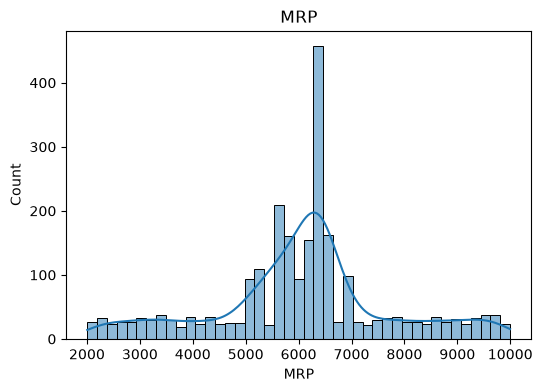

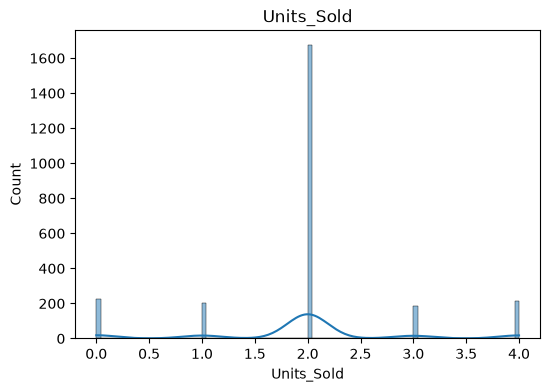

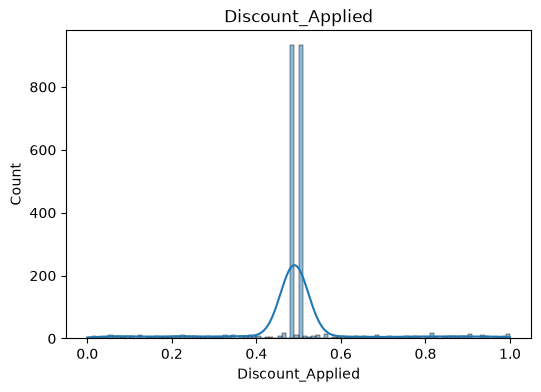

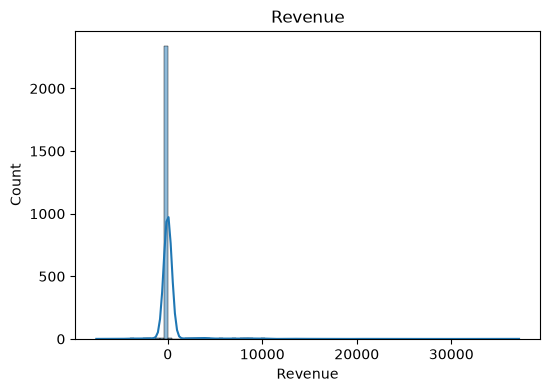

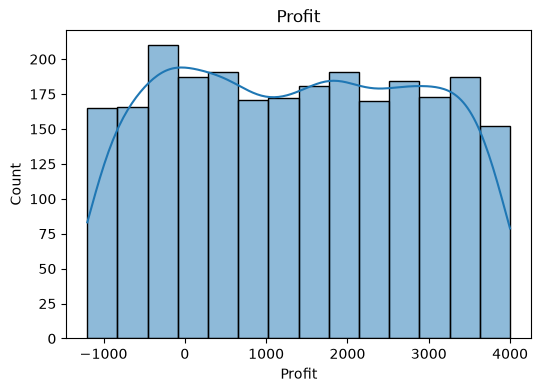

In [ ]:
numeric_cols = ['MRP','Units_Sold','Discount_Applied','Revenue','Profit']

for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

Boxplot

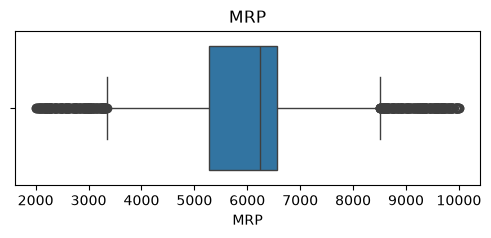

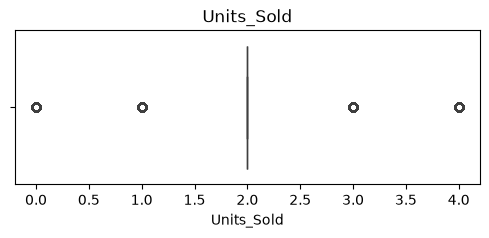

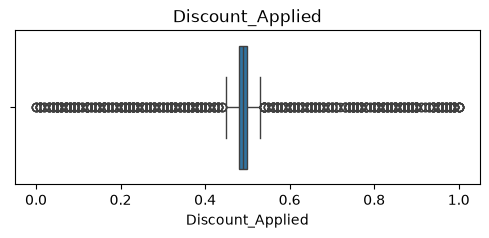

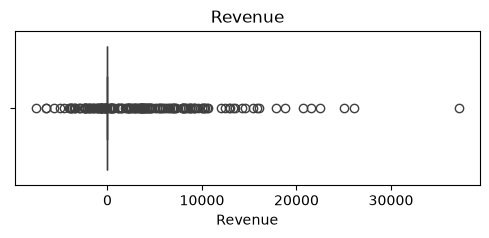

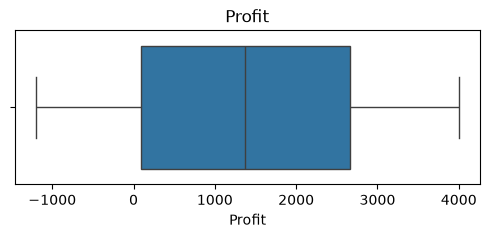

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

Bar Chart


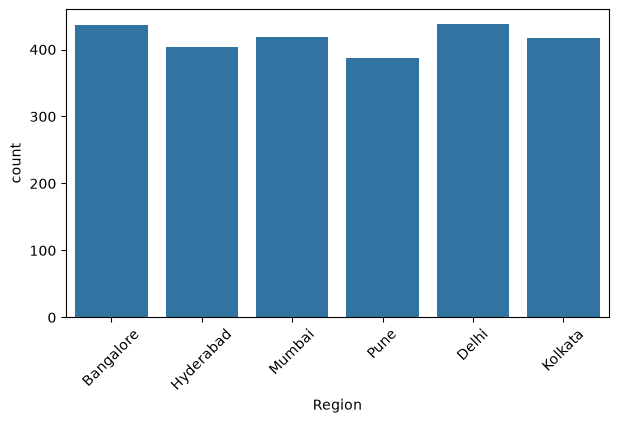

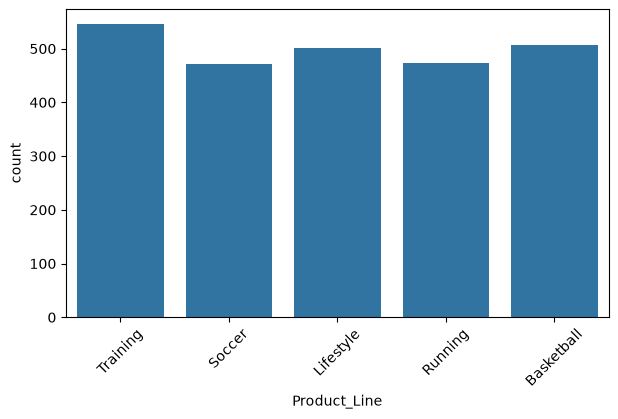

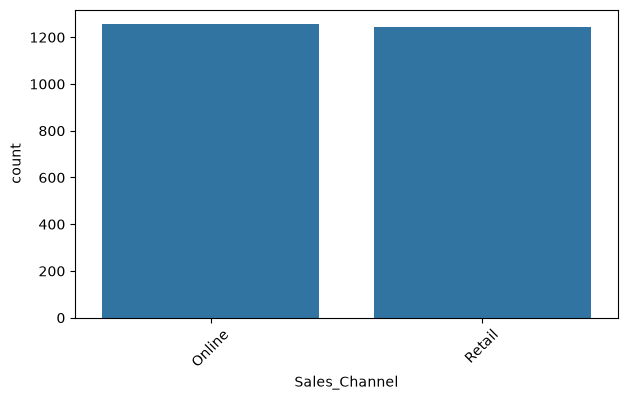

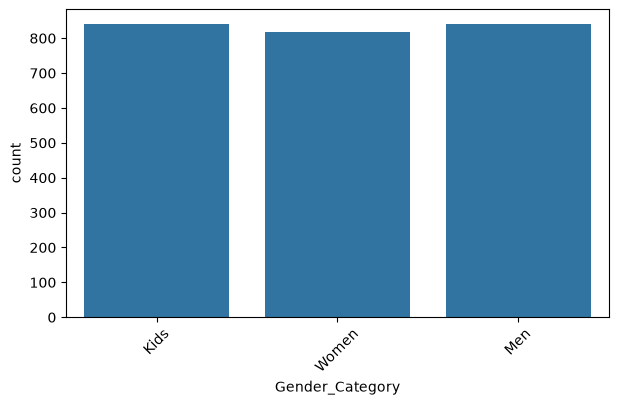

In [ ]:
cat_cols=['Region',
          'Product_Line',
          'Sales_Channel',
          'Gender_Category']

for col in cat_cols:

    plt.figure(figsize=(7,4))

    sns.countplot(data=df,x=col)

    plt.xticks(rotation=45)

    plt.show()

Correlation Analysis

Correlation Matrix


In [ ]:
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

print("Correlation Matrix")
display(corr_matrix)

Correlation Matrix


,Order_ID,Units_Sold,MRP,Discount_Applied,Revenue,Profit
Order_ID,1.000000,-0.010778,-0.041801,-0.030437,0.003626,0.036029
Units_Sold,-0.010778,1.000000,-0.002563,0.010560,0.127118,0.009701
MRP,-0.041801,-0.002563,1.000000,0.007704,0.047260,-0.027146
Discount_Applied,-0.030437,0.010560,0.007704,1.000000,-0.171431,0.013544
Revenue,0.003626,0.127118,0.047260,-0.171431,1.000000,0.002691
Profit,0.036029,0.009701,-0.027146,0.013544,0.002691,1.000000


Correlation Heatmap

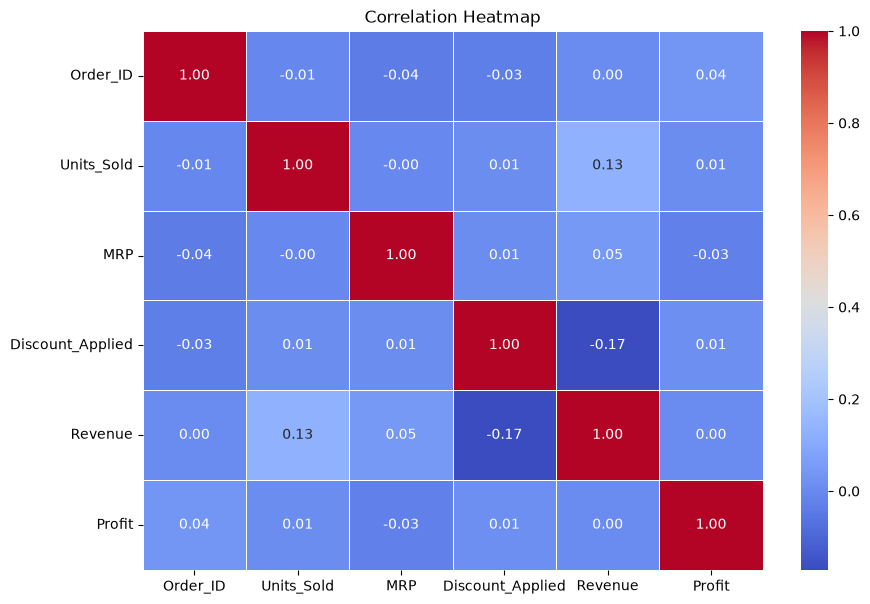

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Bivariate Analysis (Category vs Numeric)

 Product Line vs Profit

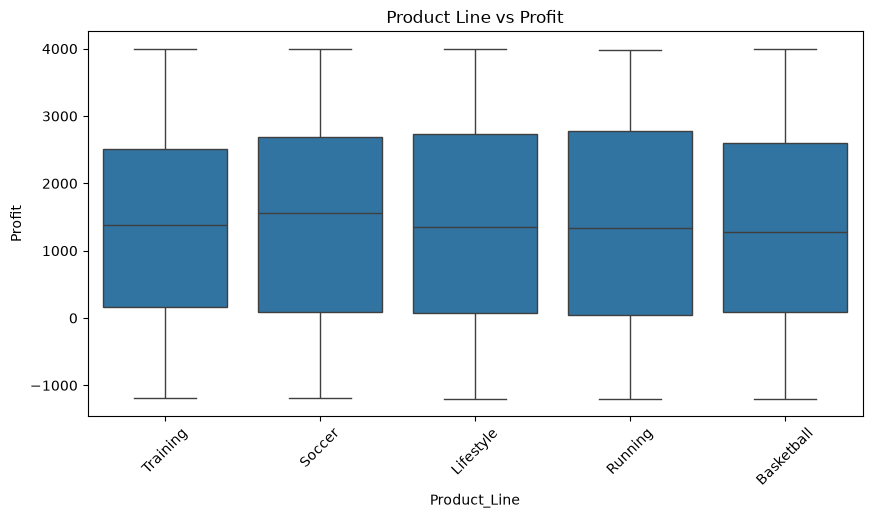

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='Product_Line', y='Profit')

plt.xticks(rotation=45)

plt.title("Product Line vs Profit")

plt.show()

Region vs Revenue

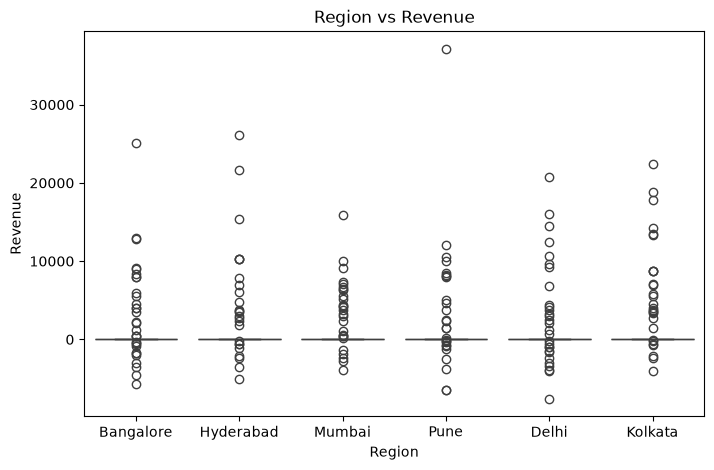

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x='Region',
            y='Revenue')

plt.title("Region vs Revenue")

plt.show()

Gender Category vs Units Sold

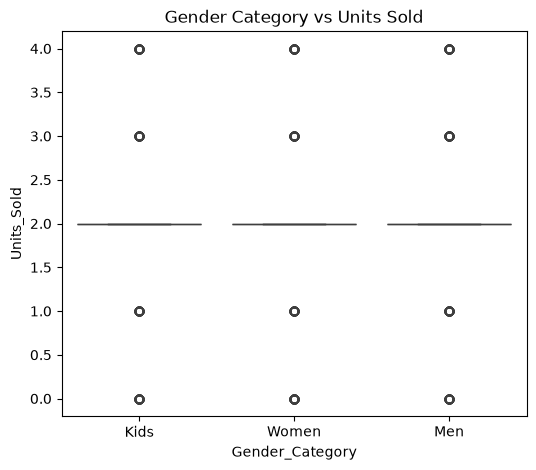

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(data=df,
            x='Gender_Category',
            y='Units_Sold')

plt.title("Gender Category vs Units Sold")

plt.show()

GroupBy Analysis

Average Profit by Product Line

In [ ]:
profit_by_product = df.groupby('Product_Line')['Profit'].mean().sort_values(ascending=False)

display(profit_by_product)

Product_Line
Soccer        1426.503008
Running       1388.878565
Lifestyle     1385.400898
Training      1351.043773
Basketball    1334.592722
Name: Profit, dtype: float64

Average Revenue by Region

In [ ]:
revenue_by_region = df.groupby('Region')['Revenue'].mean().sort_values(ascending=False)

display(revenue_by_region)

Region
Kolkata      404.318393
Hyderabad    309.403102
Pune         260.766160
Bangalore    235.654954
Mumbai       227.270502
Delhi        216.831438
Name: Revenue, dtype: float64

Units Sold by Sales Channel

In [ ]:
units_channel = df.groupby('Sales_Channel')['Units_Sold'].mean()

display(units_channel)

Sales_Channel
Online    1.996813
Retail    1.971084
Name: Units_Sold, dtype: float64

Category vs Category Analysis

Crosstab
Region vs Sales Channel

In [ ]:
region_channel = pd.crosstab(df['Region'],
                             df['Sales_Channel'])

display(region_channel)

Sales_Channel,Online,Retail
Region,,
Bangalore,229,207
Delhi,206,232
Hyderabad,196,207
Kolkata,222,195
Mumbai,205,213
Pune,197,191


Heatmap

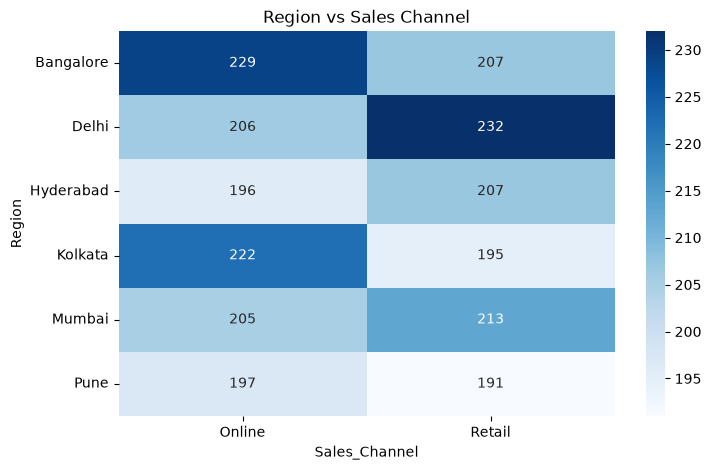

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(region_channel,
            annot=True,
            cmap='Blues',
            fmt='d')

plt.title("Region vs Sales Channel")

plt.show()

Stacked Bar Chart

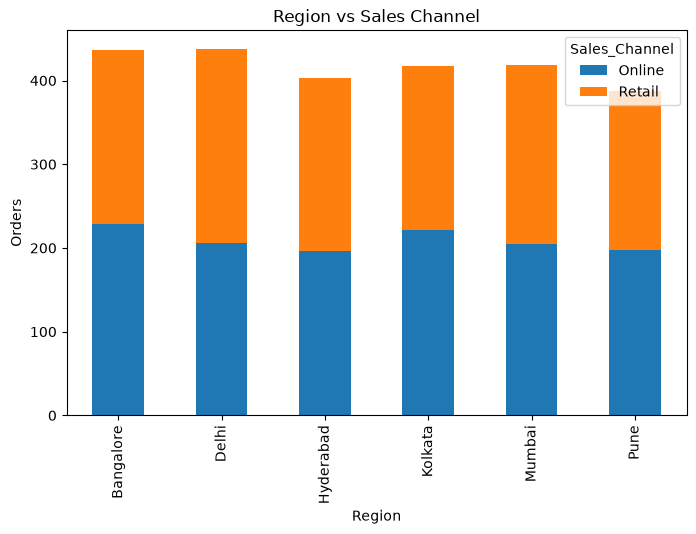

In [ ]:
region_channel.plot(kind='bar',
                    stacked=True,
                    figsize=(8,5))

plt.title("Region vs Sales Channel")

plt.ylabel("Orders")

plt.show()

Gender vs Size

In [ ]:
gender_size = pd.crosstab(df['Gender_Category'],
                          df['Size'])

display(gender_size)

Size,10,11,12,6,7,8,9,L,M,XL
Gender_Category,,,,,,,,,,
Kids,45,30,30,26,32,25,34,212,205,202
Men,27,26,22,18,36,18,28,217,199,249
Women,35,41,24,31,41,25,25,211,194,192


Gender vs Size

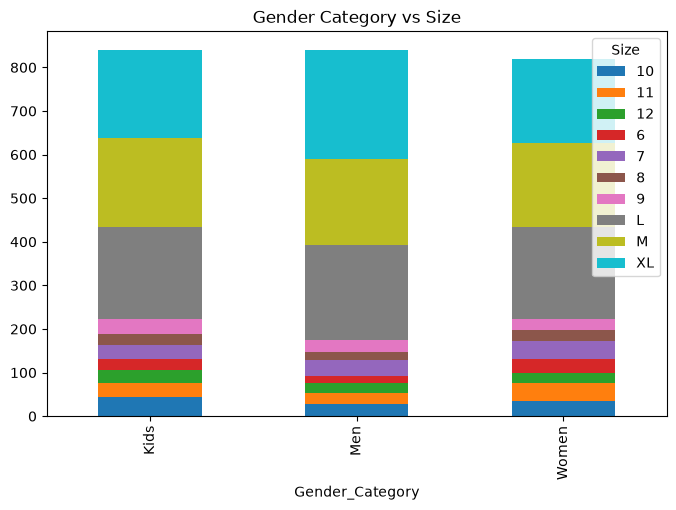

In [ ]:
gender_size.plot(kind='bar',
                 stacked=True,
                 figsize=(8,5))

plt.title("Gender Category vs Size")

plt.show()

Time-Based Trends

Extract Date Features

In [ ]:
df['Year'] = df['Order_Date'].dt.year

df['Month'] = df['Order_Date'].dt.month_name()

df['Weekday'] = df['Order_Date'].dt.day_name()

Monthly Revenue

In [ ]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()

display(monthly_revenue)

Month
April         58687.59
August        52072.87
December     155862.51
February      43785.76
January       43665.12
July          25869.42
June          50574.78
March         46735.91
May           51025.26
November      63022.95
October       25955.83
September     69926.29
Name: Revenue, dtype: float64

Line Chart

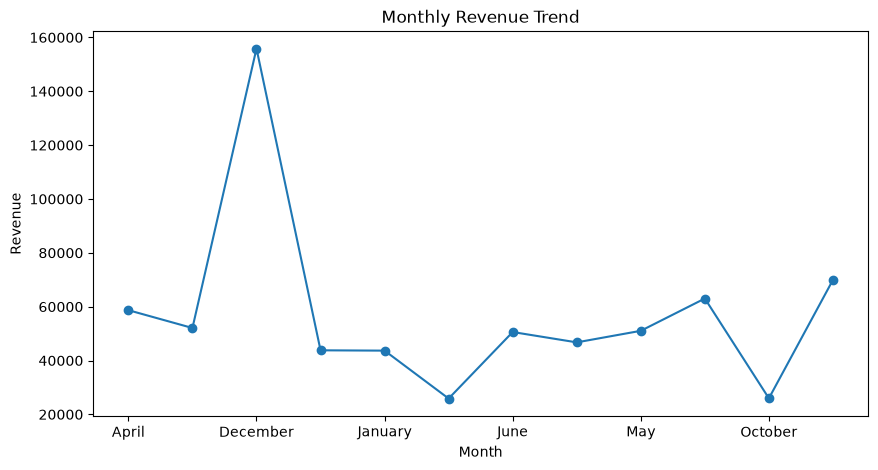

In [ ]:
plt.figure(figsize=(10,5))

monthly_revenue.plot(marker='o')

plt.title("Monthly Revenue Trend")

plt.ylabel("Revenue")

plt.show()

Monthly Profit

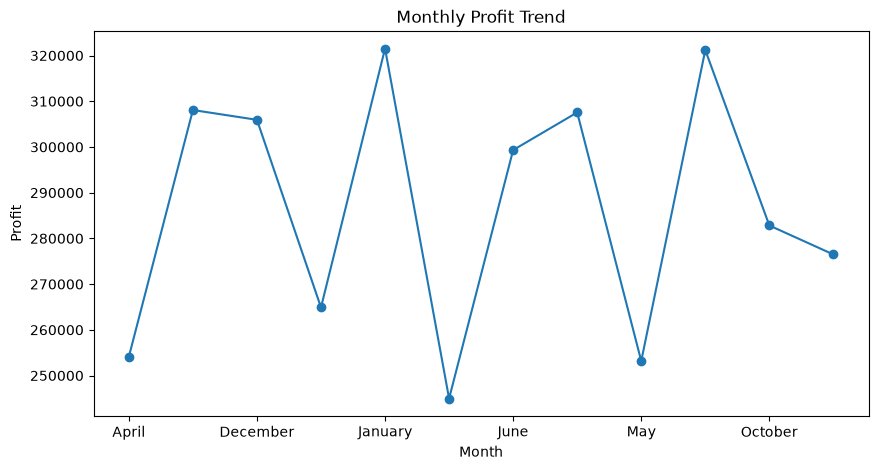

In [ ]:
monthly_profit = df.groupby('Month')['Profit'].sum()

plt.figure(figsize=(10,5))

monthly_profit.plot(marker='o')

plt.title("Monthly Profit Trend")

plt.ylabel("Profit")

plt.show()

Weekday Sales

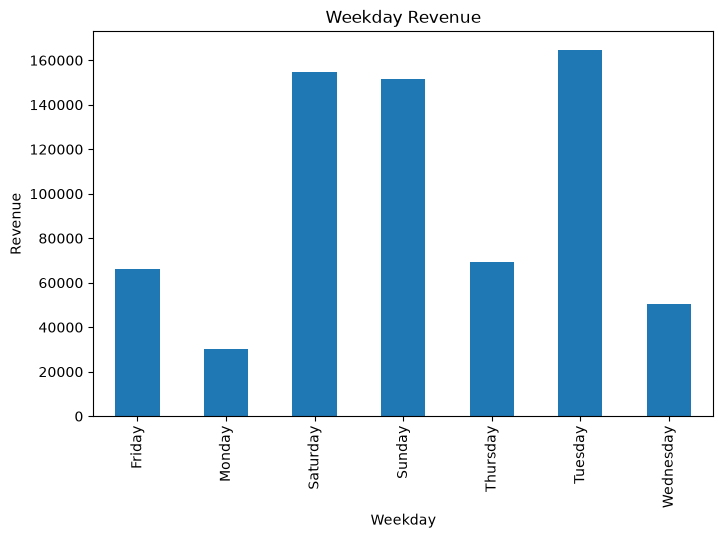

In [ ]:
weekday_sales = df.groupby('Weekday')['Revenue'].sum()

plt.figure(figsize=(8,5))

weekday_sales.plot(kind='bar')

plt.title("Weekday Revenue")

plt.ylabel("Revenue")

plt.show()

Outlier Detection

IQR Method

In [ ]:
numeric_cols = ['MRP',
                'Units_Sold',
                'Discount_Applied',
                'Revenue',
                'Profit']

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) |
                  (df[col] > upper)]

    print(f"{col}: {len(outliers)} Outliers")

MRP: 452 Outliers
Units_Sold: 826 Outliers
Discount_Applied: 578 Outliers
Revenue: 166 Outliers
Profit: 0 Outliers


Boxplots

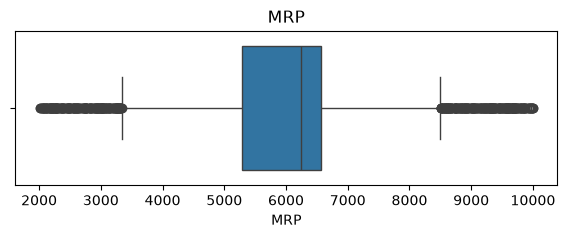

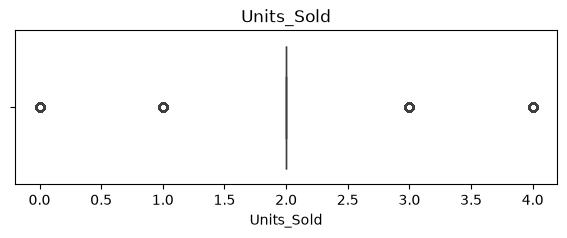

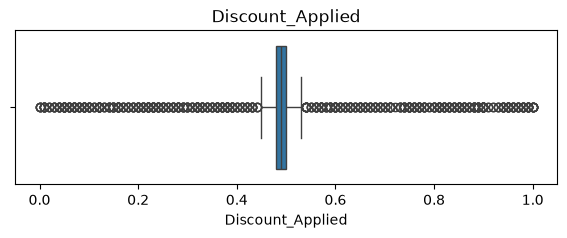

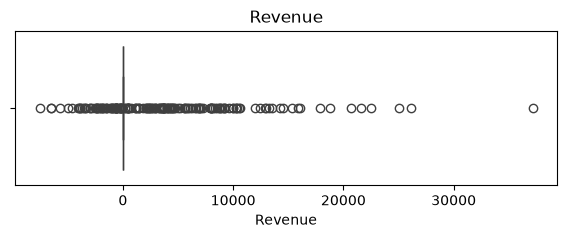

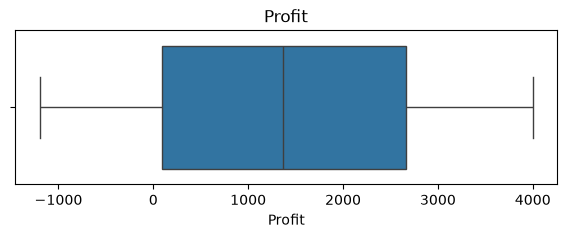

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(7,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

Multivariate Analysis

Pair Plot


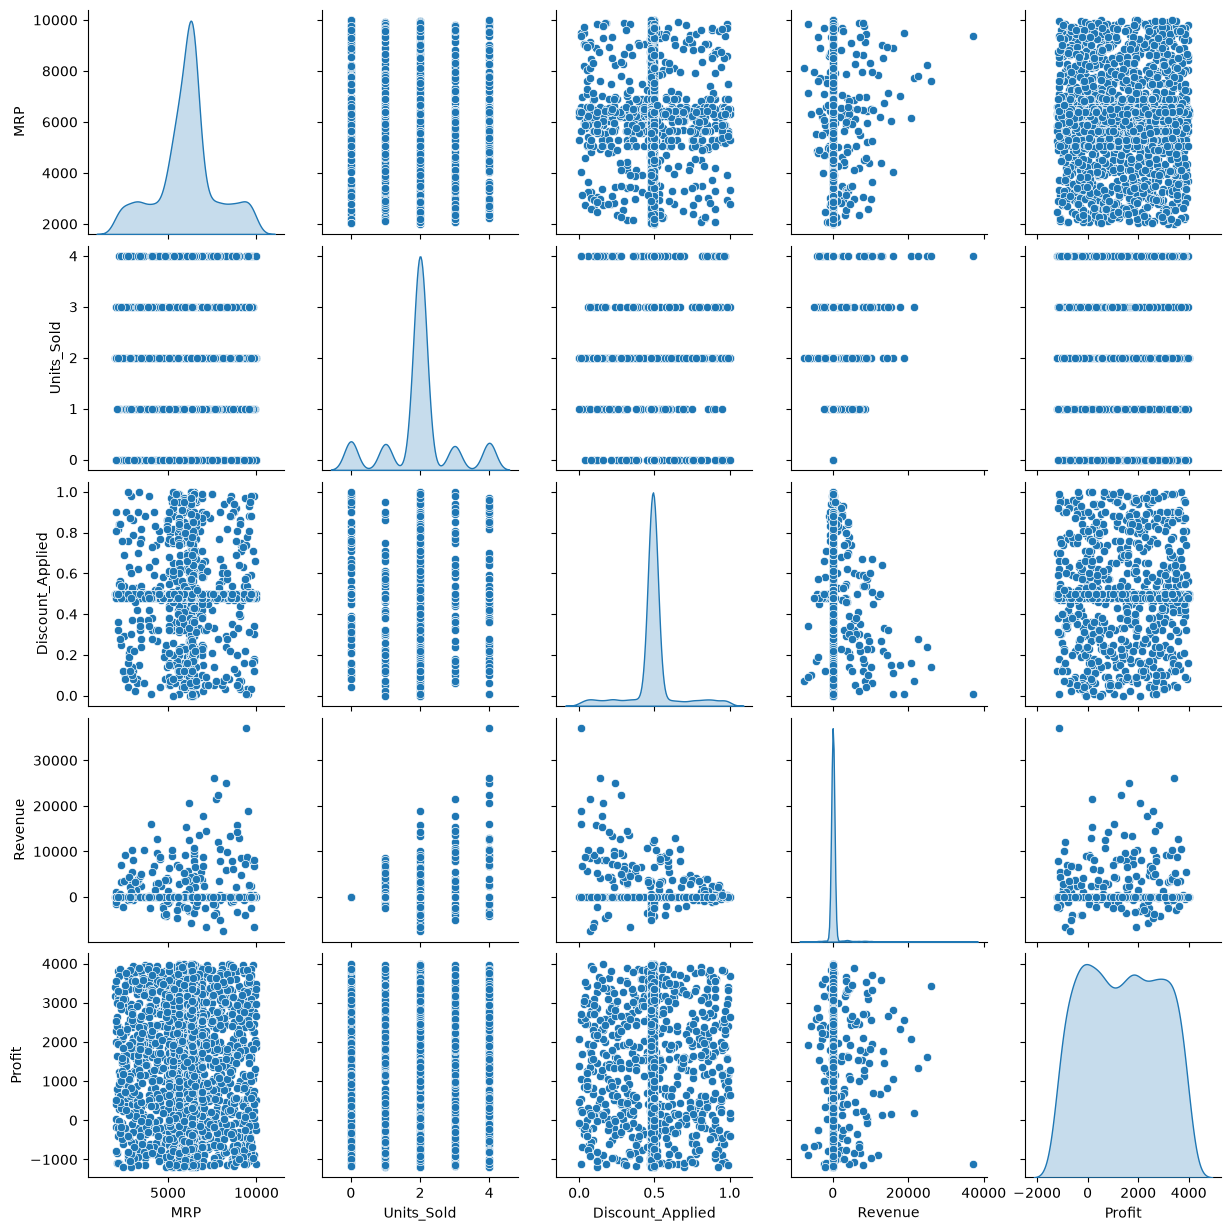

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_cols = ['MRP',
                'Units_Sold',
                'Discount_Applied',
                'Revenue',
                'Profit']

sns.pairplot(
    df[numeric_cols],
    diag_kind='kde'
)

plt.show()

Pairplot with Product Line

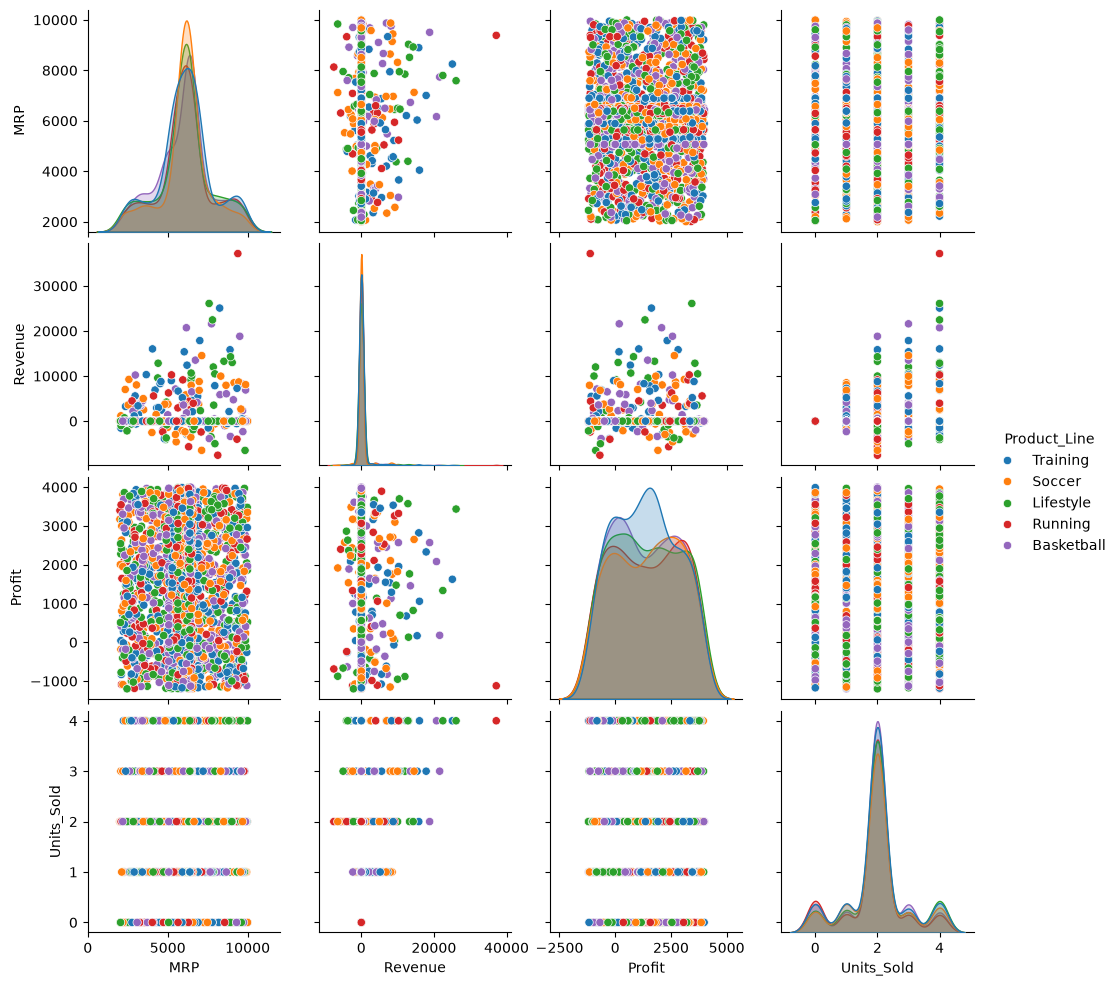

In [ ]:
sns.pairplot(
    df,
    vars=['MRP',
          'Revenue',
          'Profit',
          'Units_Sold'],
    hue='Product_Line'
)

plt.show()

Statistical Hypothesis Testing

ANOVA Test

In [ ]:
from scipy.stats import f_oneway

groups = []

for region in df['Region'].unique():
    groups.append(
        df[df['Region']==region]['Profit']
    )

f_stat, p_value = f_oneway(*groups)

print("F Statistic:",f_stat)

print("P Value:",p_value)

F Statistic: 0.5404431018169509
P Value: 0.7457549411021076


Chi Square Test

In [ ]:
from scipy.stats import chi2_contingency

# Create contingency table
table = pd.crosstab(
    df['Region'],
    df['Sales_Channel']
)

# Perform Chi-Square Test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p)
print("Degrees of Freedom:", dof)

print("\nExpected Frequencies:")
print(expected)

Chi-Square Statistic: 4.907892395639653
P-Value: 0.42722433971647633
Degrees of Freedom: 5

Expected Frequencies:
[[218.872 217.128]
 [219.876 218.124]
 [202.306 200.694]
 [209.334 207.666]
 [209.836 208.164]
 [194.776 193.224]]


Discount Impact Analysis

Discount vs Revenue


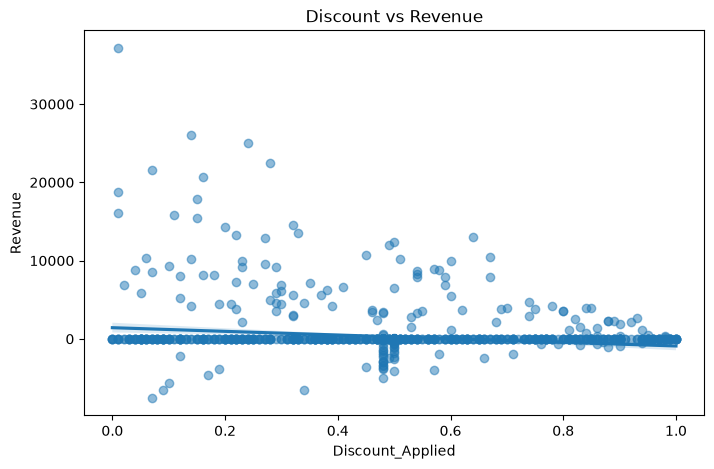

In [ ]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='Discount_Applied',
    y='Revenue',
    scatter_kws={'alpha':0.5}
)

plt.title("Discount vs Revenue")

plt.show()

Discount vs Profit

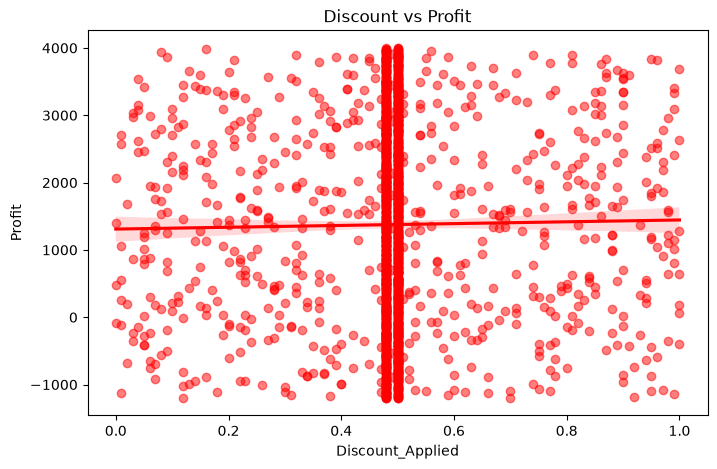

In [ ]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='Discount_Applied',
    y='Profit',
    scatter_kws={'alpha':0.5},
    color='red'
)

plt.title("Discount vs Profit")

plt.show()

Product Segmentation

Pivot Table


In [ ]:
pivot = pd.pivot_table(
    df,
    values=['Revenue',
            'Profit',
            'Units_Sold'],
    index='Product_Line',
    columns='Region',
    aggfunc='sum'
)

display(pivot)

Profit                                              \
Region        Bangalore      Delhi  Hyderabad    Kolkata     Mumbai   
Product_Line                                                          
Basketball    117792.76  117918.86  113402.40  122286.95  106629.52   
Lifestyle     116474.05  106454.11  126205.47  128684.23  114910.46   
Running       123906.48  119158.87   95424.82  100622.17  113162.67   
Soccer        110806.13  115055.03  101219.34  130762.75  119685.16   
Training      152969.32  128562.06   88842.57  120500.64  115180.53   

                          Revenue                                          \
Region             Pune Bangalore     Delhi Hyderabad   Kolkata    Mumbai   
Product_Line                                                                
Basketball     98608.02  13882.11  14273.86  57271.55  46263.07  11687.01   
Lifestyle     101357.53  28982.65  15892.33  15468.93  53464.62  24926.35   
Running       106053.43  13417.31   2831.35  14147.06  -1921.59   6677.10   
Soccer         95781.01   6007.37  34479.00   3761.39  28890.86   8598.61   
Training      131614.78  40456.12  27495.63  34040.52  41903.81  43110.00   

                       Units_Sold                                      
Region            Pune  Bangalore Delhi Hyderabad Kolkata Mumbai Pune  
Product_Line                                                           
Basketball    11914.82        151   180       170     177    181  139  
Lifestyle     10135.82        176   156       198     158    191  153  
Running       36924.72        157   164       135     163    151  129  
Soccer        33655.10        158   171       158     165    142  150  
Training       8546.81        204   185       145     151    206  196

Top Products

In [ ]:
top_products = df.groupby(
    'Product_Line'
)['Revenue'].sum().sort_values(
    ascending=False
)

display(top_products)

Product_Line
Training      195552.89
Basketball    155292.42
Lifestyle     148870.70
Soccer        115392.33
Running        72075.95
Name: Revenue, dtype: float64

Top Regions

In [ ]:
top_regions = df.groupby(
    'Region'
)['Revenue'].sum().sort_values(
    ascending=False
)

display(top_regions)

Region
Kolkata      168600.77
Hyderabad    124689.45
Bangalore    102745.56
Pune         101177.27
Mumbai        94999.07
Delhi         94972.17
Name: Revenue, dtype: float64

Revenue Anomaly Investigation

In [ ]:
zero_rev = df[
    df['Revenue']==0
]

print(zero_rev.shape)

display(zero_rev.head())

(2334, 17)


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,Is_Duplicate_Order_ID,Year,Month,Weekday
0,2000,Kids,Training,SuperRep Go,M,2,5280.57,0.47,0.0,2024-03-09,Online,Bangalore,-770.45,True,2024,March,Saturday
1,2001,Women,Soccer,Tiempo Legend,M,3,4957.93,0.48,0.0,2024-07-09,Retail,Hyderabad,-112.53,False,2024,July,Tuesday
2,2002,Women,Soccer,Premier III,M,4,5773.24,0.48,0.0,2025-01-29,Retail,Mumbai,3337.34,True,2025,January,Wednesday
3,2003,Kids,Lifestyle,Blazer Mid,L,2,9673.57,0.50,0.0,2024-10-04,Online,Pune,3376.85,True,2024,October,Friday
4,2004,Kids,Running,React Infinity,XL,2,6492.16,0.48,0.0,2024-09-12,Retail,Delhi,187.89,True,2024,September,Thursday


Region wise

In [ ]:
display(
zero_rev['Region'].value_counts()
)

Region
Delhi        409
Bangalore    405
Mumbai       391
Kolkata      389
Hyderabad    378
Pune         362
Name: count, dtype: int64

Product wise

In [ ]:
display(
zero_rev['Product_Line'].value_counts()
)

Product_Line
Training      505
Basketball    472
Lifestyle     470
Running       452
Soccer        435
Name: count, dtype: int64

Sales Channel

In [ ]:
display(
zero_rev['Sales_Channel'].value_counts()
)

Sales_Channel
Online    1178
Retail    1156
Name: count, dtype: int64

Executive Dashboard


In [ ]:
print("Total Revenue:",df['Revenue'].sum())

print("Total Profit:",df['Profit'].sum())

print("Average Profit:",df['Profit'].mean())

print("Total Orders:",len(df))

print("Top Region:",
df.groupby('Region')['Revenue'].sum().idxmax())

print("Top Product:",
df.groupby('Product_Line')['Revenue'].sum().idxmax())

Total Revenue: 687184.29
Total Profit: 3440032.12
Average Profit: 1376.012848
Total Orders: 2500
Top Region: Kolkata
Top Product: Training
